# ¿Por qué te da hambre después de estudiar?

No es falta de voluntad. Un sensor de azúcar en tu cerebro conecta la memoria con el hambre — y el entrenamiento "espaciado" (el que de verdad funciona) es el que más hambre da.

---

📄 **Paper:** [Internal sugar sensing drives non-homeostatic hunger during memory consolidation](https://doi.org/10.1038/s41586-026-10306-z) — *Nature* (2026)
🎬 **Video:** [Ver en YouTube](https://youtube.com/shorts/e14oe0wa2bY)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-30-hambre-despues-estudiar/notebook.ipynb)

## El circuito hambre-memoria

En el cerebro de *Drosophila* (la mosca de la fruta), hay neuronas que sensan fructosa llamadas **Gr43a**. Ya se sabía que participaban en la formación de memorias relacionadas con comida. Lo que nadie esperaba: estas mismas neuronas son necesarias para consolidar **cualquier** memoria a largo plazo — incluso las que no tienen nada que ver con comida.

El truco: el entrenamiento **espaciado** (repeticiones separadas por descansos) — el mismo que funciona mejor para estudiar — activa estas neuronas de azúcar y genera hambre *después* de aprender. Es un "hambre emocional" no homeostática: no tiene que ver con cuánto comiste, sino con que tu cerebro acaba de aprender algo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_MEMORIA = 30       # Índice mínimo para considerar "buena memoria"
FUENTE = 'Fuente: Ichinose et al. (2026), Nature | Datos: Supplementary Materials'
COLOR_DATOS = '#2563EB'       # Azul CaM
COLOR_ALERTA = '#DC2626'      # Rojo
COLOR_SECUNDARIO = '#059669'  # Emerald
COLOR_REFERENCIA = '#D97706'  # Amber
COLOR_VIOLETA = '#7C3AED'     # Violeta

# ══════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Descargar datos si no están locales
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/papers/2026-03-30-hambre-despues-estudiar/datos'
os.makedirs('datos', exist_ok=True)
os.makedirs('figuras', exist_ok=True)

archivos = [
    'memoria_tipo_entrenamiento.csv',
    'silenciar_gr43a.csv',
    'preferencia_sucrosa.csv',
    'preferencia_knockdown_gr43a.csv'
]
for archivo in archivos:
    ruta = f'datos/{archivo}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/{archivo}', ruta)

# Cargar
memoria = pd.read_csv('datos/memoria_tipo_entrenamiento.csv')
silenciar = pd.read_csv('datos/silenciar_gr43a.csv')
preferencia = pd.read_csv('datos/preferencia_sucrosa.csv')
knockdown = pd.read_csv('datos/preferencia_knockdown_gr43a.csv')

print('Datos cargados:')
print(f'  Memoria (entrenamiento): {len(memoria)} mediciones')
print(f'  Silenciar Gr43a: {len(silenciar)} mediciones')
print(f'  Preferencia sucrosa: {len(preferencia)} mediciones')
print(f'  Knockdown Gr43a: {len(knockdown)} mediciones')

Datos cargados:
  Memoria (entrenamiento): 48 mediciones
  Silenciar Gr43a: 102 mediciones
  Preferencia sucrosa: 65 mediciones
  Knockdown Gr43a: 100 mediciones


## Solo un tipo de estudio consolida memoria

Aquí está.

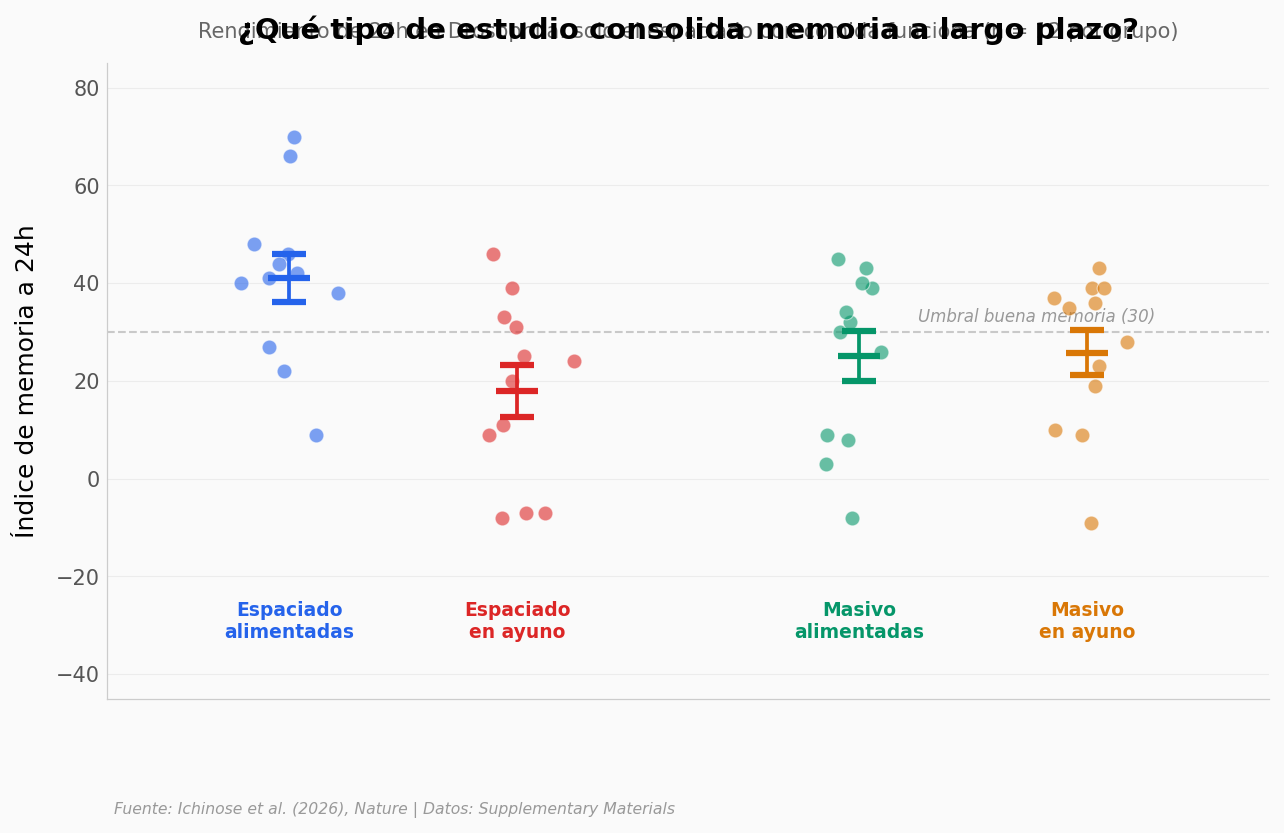

In [2]:
# Gráfica hero: memoria por tipo de entrenamiento y condición
fig, ax = plt.subplots(figsize=(10, 5.5))

groups = [
    ('spaced', 'fed', 'Espaciado\nalimentadas', COLOR_DATOS),
    ('spaced', 'starved', 'Espaciado\nen ayuno', COLOR_ALERTA),
    ('massed', 'fed', 'Masivo\nalimentadas', COLOR_SECUNDARIO),
    ('massed', 'starved', 'Masivo\nen ayuno', COLOR_REFERENCIA),
]

positions = [0, 1, 2.5, 3.5]
for i, (train, cond, label, color) in enumerate(groups):
    vals = memoria[(memoria.training == train) & (memoria.condition == cond)]['memory_index'].values
    
    # Jitter scatter
    x_jitter = np.random.normal(positions[i], 0.08, len(vals))
    ax.scatter(x_jitter, vals, color=color, s=50, alpha=0.6,
              edgecolors='white', linewidths=0.5, zorder=5)
    
    # Media ± SEM
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=20, markeredgewidth=3, capsize=8, capthick=2, zorder=6)

# Línea de umbral
ax.axhline(y=UMBRAL_MEMORIA, color='#999999', linewidth=1, linestyle='--', alpha=0.5)
ax.text(3.8, UMBRAL_MEMORIA + 2, f'Umbral buena memoria ({UMBRAL_MEMORIA})',
        fontsize=8, color='#999999', style='italic', ha='right')

# Inline labels
for i, (_, _, label, color) in enumerate(groups):
    ax.text(positions[i], -25, label, fontsize=9, fontweight='bold',
            color=color, ha='center', va='top')

ax.set_ylabel('Índice de memoria a 24h', fontsize=12)
ax.set_title('¿Qué tipo de estudio consolida memoria a largo plazo?', fontsize=14, fontweight='bold', pad=12)
ax.text(0.5, 1.04, 'Rendimiento de 24h en Drosophila: solo el espaciado con comida funciona (n = 12 por grupo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.set_xlim(-0.8, 4.3)
ax.set_xticks([])
ax.set_ylim(-45, 85)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/memoria_tipo_entrenamiento.png', dpi=200, bbox_inches='tight')
plt.show()

Cada punto es una medición individual. Las barras horizontales son la media ± error estándar.

El grupo **azul** (espaciado, alimentadas) tiene la media más alta: **41.1** puntos. El grupo **rojo** (espaciado, en ayuno) cae a **18.0** — 23 puntos menos (p = 0.004, Cohen's d = 1.30, n = 12 por grupo).

Pero lo más revelador: los grupos de entrenamiento **masivo** (verde y ámbar) rinden ~25 puntos sin importar si las moscas están alimentadas o en ayuno (p = 0.92, no significativo). El ayuno solo penaliza cuando el entrenamiento es el que realmente consolida memoria.

## ¿Qué pasa si silencias las neuronas de azúcar?

Si las neuronas Gr43a son necesarias para la memoria, silenciarlas debería bloquear la consolidación. Los autores usaron Shits (una herramienta genética que desactiva neuronas con temperatura).

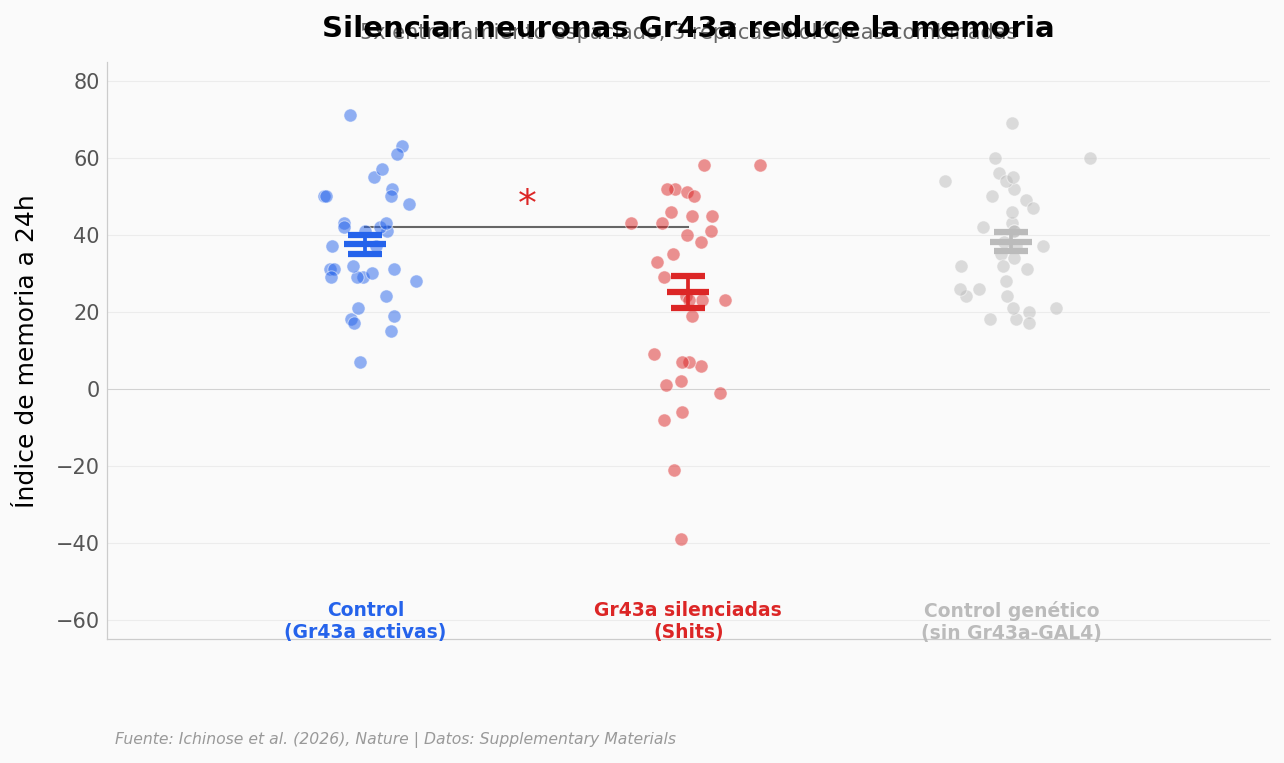

Control: 37.5 ± 15.1 (n=34)
Silenciadas: 25.1 ± 24.4 (n=33)
t-test: t=2.51, p=0.0146


In [3]:
# Silenciar Gr43a: efecto en memoria
fig, ax = plt.subplots(figsize=(10, 5))

genotypes = ['Gr43a > empty', 'Gr43a > Shits', 'empty > Shits']
labels = ['Control\n(Gr43a activas)', 'Gr43a silenciadas\n(Shits)', 'Control genético\n(sin Gr43a-GAL4)']
colors = [COLOR_DATOS, COLOR_ALERTA, '#BBBBBB']

for i, (geno, label, color) in enumerate(zip(genotypes, labels, colors)):
    vals = silenciar[silenciar.genotype == geno]['memory_index'].values
    
    x_jitter = np.random.normal(i, 0.08, len(vals))
    ax.scatter(x_jitter, vals, color=color, s=40, alpha=0.5,
              edgecolors='white', linewidths=0.5, zorder=5)
    
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(i, mean, yerr=sem, fmt='_', color=color,
                markersize=20, markeredgewidth=3, capsize=8, capthick=2, zorder=6)
    
    ax.text(i, -55, label, fontsize=9, fontweight='bold', color=color, ha='center', va='top')

# Significancia
ax.annotate('*', xy=(0.5, 45), fontsize=18, ha='center', color=COLOR_ALERTA)
ax.plot([0, 1], [42, 42], color='#666666', linewidth=1)

ax.axhline(y=0, color='#999999', linewidth=0.5, alpha=0.3)
ax.set_ylabel('Índice de memoria a 24h', fontsize=12)
ax.set_title('Silenciar neuronas Gr43a reduce la memoria', fontsize=14, fontweight='bold', pad=12)
ax.text(0.5, 1.04, '5x entrenamiento espaciado, 3 réplicas biológicas combinadas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(-0.8, 2.8)
ax.set_xticks([])
ax.set_ylim(-65, 85)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/silenciar_gr43a.png', dpi=200, bbox_inches='tight')
plt.show()

from scipy import stats
ctrl = silenciar[silenciar.genotype == 'Gr43a > empty']['memory_index'].values
shits = silenciar[silenciar.genotype == 'Gr43a > Shits']['memory_index'].values
t_stat, p_val = stats.ttest_ind(ctrl, shits)
print(f'Control: {ctrl.mean():.1f} ± {ctrl.std(ddof=1):.1f} (n={len(ctrl)})')
print(f'Silenciadas: {shits.mean():.1f} ± {shits.std(ddof=1):.1f} (n={len(shits)})')
print(f't-test: t={t_stat:.2f}, p={p_val:.4f}')

Silenciar las neuronas Gr43a baja la memoria de 37.5 a 25.1 puntos (p = 0.015, Cohen's d = 0.61 — efecto medio). El control genético (empty > Shits, gris) se mantiene alto (38.2), confirmando que el efecto es específico de las neuronas Gr43a.

Nota: la variabilidad es alta (SD = 24.4 para Shits vs 15.1 para control), lo que sugiere que el silenciamiento no es todo-o-nada — algunas moscas mantienen cierta capacidad.

## Y ahora lo inesperado: el hambre post-estudio

Aquí es donde la historia se vuelve fascinante. Si las neuronas Gr43a se activan después de aprender, ¿las moscas sienten hambre? Los autores midieron la **preferencia por sucrosa** después del entrenamiento espaciado.

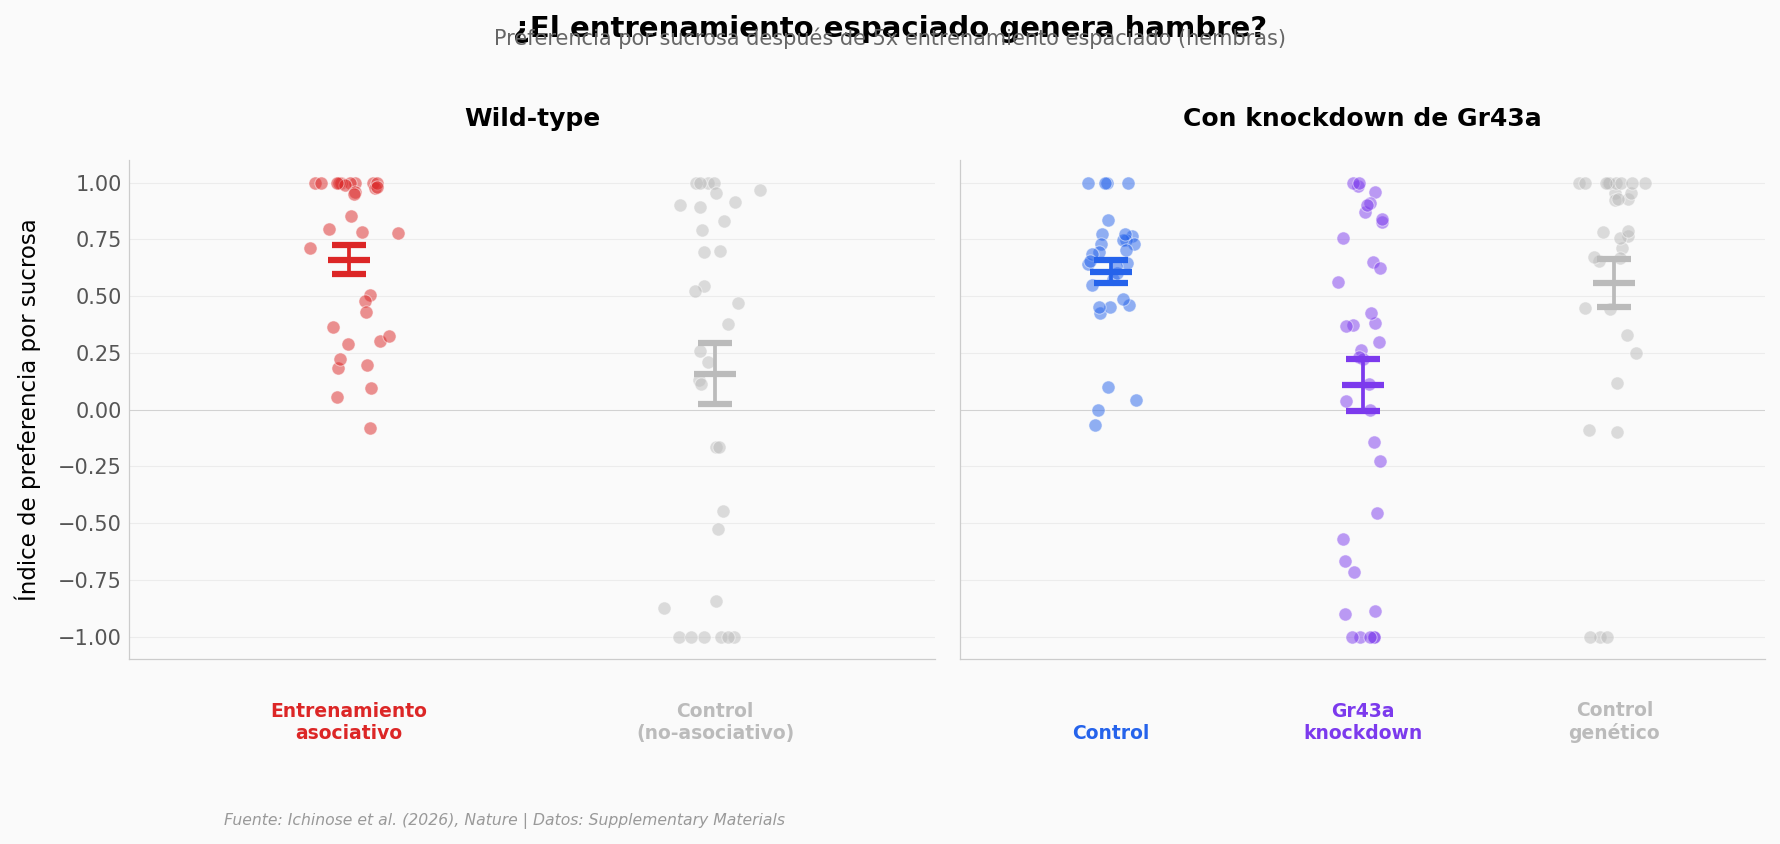

Wild-type — Asociativo: 0.661±0.362 (n=32)
Wild-type — No-asociativo: 0.159±0.767 (n=33)
Mann-Whitney: U=730, p=0.0079

Knockdown — Control: 0.607±0.281 (n=31)
Knockdown — RNAi: 0.109±0.706 (n=37)
Mann-Whitney: U=802, p=0.0051


In [4]:
# Preferencia de sucrosa: asociativo vs no-asociativo
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Panel 1: Wild-type
ax = axes[0]
for cond, color, label, pos in [('associative', COLOR_ALERTA, 'Entrenamiento\nasociativo', 0),
                                   ('unpaired', '#BBBBBB', 'Control\n(no-asociativo)', 1)]:
    vals = preferencia[preferencia.condition == cond]['sucrose_preference'].values
    x_jitter = np.random.normal(pos, 0.06, len(vals))
    ax.scatter(x_jitter, vals, color=color, s=40, alpha=0.5,
              edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                markersize=20, markeredgewidth=3, capsize=8, capthick=2, zorder=6)
    ax.text(pos, -1.45, label, fontsize=9, fontweight='bold', color=color, ha='center')

ax.axhline(y=0, color='#999999', linewidth=0.5, alpha=0.3)
ax.set_ylabel('Índice de preferencia por sucrosa', fontsize=11)
ax.set_title('Wild-type', fontsize=12, fontweight='bold')
ax.set_xlim(-0.6, 1.6)
ax.set_xticks([])

# Panel 2: Gr43a knockdown
ax = axes[1]
for geno, color, label, pos in [('Gr43a > empty', COLOR_DATOS, 'Control', 0),
                                   ('Gr43a > RNAi', COLOR_VIOLETA, 'Gr43a\nknockdown', 1),
                                   ('empty > RNAi', '#BBBBBB', 'Control\ngenético', 2)]:
    vals = knockdown[knockdown.genotype == geno]['sucrose_preference'].values
    x_jitter = np.random.normal(pos, 0.06, len(vals))
    ax.scatter(x_jitter, vals, color=color, s=40, alpha=0.5,
              edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                markersize=20, markeredgewidth=3, capsize=8, capthick=2, zorder=6)
    ax.text(pos, -1.45, label, fontsize=9, fontweight='bold', color=color, ha='center')

ax.axhline(y=0, color='#999999', linewidth=0.5, alpha=0.3)
ax.set_title('Con knockdown de Gr43a', fontsize=12, fontweight='bold')
ax.set_xlim(-0.6, 2.6)
ax.set_xticks([])

fig.suptitle('¿El entrenamiento espaciado genera hambre?', fontsize=14, fontweight='bold', y=1.02)
fig.text(0.5, 0.98, 'Preferencia por sucrosa después de 5x entrenamiento espaciado (hembras)',
         fontsize=10, color='#666666', ha='center', transform=fig.transFigure)

fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/preferencia_sucrosa.png', dpi=200, bbox_inches='tight')
plt.show()

from scipy import stats
a = preferencia[preferencia.condition=='associative']['sucrose_preference'].values
u = preferencia[preferencia.condition=='unpaired']['sucrose_preference'].values
# No normal → Mann-Whitney
mw_stat, mw_p = stats.mannwhitneyu(a, u, alternative='two-sided')
print(f'Wild-type — Asociativo: {a.mean():.3f}±{a.std(ddof=1):.3f} (n={len(a)})')
print(f'Wild-type — No-asociativo: {u.mean():.3f}±{u.std(ddof=1):.3f} (n={len(u)})')
print(f'Mann-Whitney: U={mw_stat:.0f}, p={mw_p:.4f}')

c = knockdown[knockdown.genotype=='Gr43a > empty']['sucrose_preference'].values
r = knockdown[knockdown.genotype=='Gr43a > RNAi']['sucrose_preference'].values
mw2, mw2_p = stats.mannwhitneyu(c, r, alternative='two-sided')
print(f'\nKnockdown — Control: {c.mean():.3f}±{c.std(ddof=1):.3f} (n={len(c)})')
print(f'Knockdown — RNAi: {r.mean():.3f}±{r.std(ddof=1):.3f} (n={len(r)})')
print(f'Mann-Whitney: U={mw2:.0f}, p={mw2_p:.4f}')

## ¿Cuánto aumenta el hambre?

Para dimensionar el efecto, veamos la distribución completa de la preferencia por sucrosa en las moscas que aprendieron vs las que no.

Asociativo: mediana=0.788, media=0.661 (n=32)
No-asociativo: mediana=0.375, media=0.159 (n=33)
Mann-Whitney U: U=730, p=0.0079
Nota: distribuciones NO normales (Shapiro p < 0.001 para ambas) → Mann-Whitney es el test apropiado


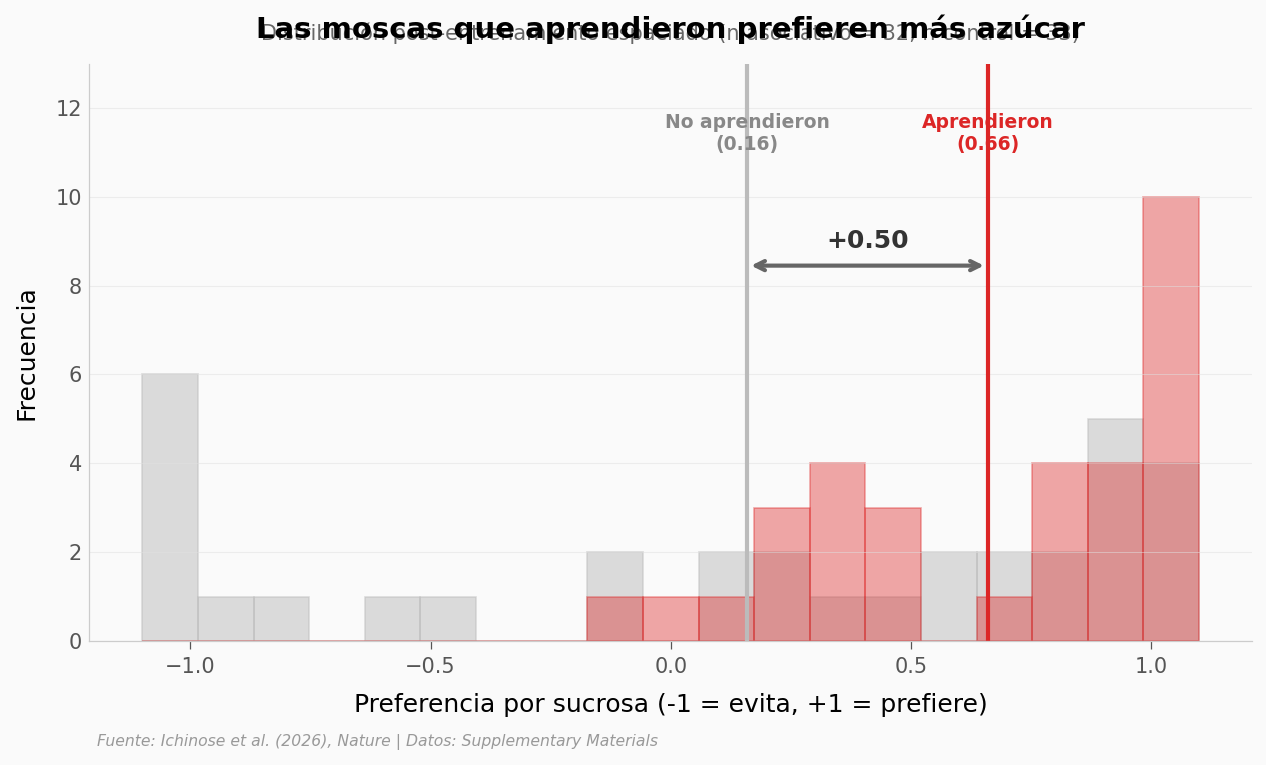

In [5]:
# Histograma: distribución de preferencia por sucrosa
assoc = preferencia[preferencia.condition == 'associative']['sucrose_preference'].values
unpair = preferencia[preferencia.condition == 'unpaired']['sucrose_preference'].values

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(-1.1, 1.1, 20)
n1, _, _ = ax.hist(unpair, bins=bins, color='#BBBBBB', alpha=0.5,
                   edgecolor='#BBBBBB', linewidth=0.8, label='No-asociativo')
n2, _, _ = ax.hist(assoc, bins=bins, color=COLOR_ALERTA, alpha=0.4,
                   edgecolor=COLOR_ALERTA, linewidth=0.8, label='Asociativo')

# Medias
media_assoc = assoc.mean()
media_unpair = unpair.mean()
y_max = max(n1.max(), n2.max()) * 1.3

ax.axvline(x=media_unpair, color='#BBBBBB', linewidth=2)
ax.axvline(x=media_assoc, color=COLOR_ALERTA, linewidth=2)

# Flecha
y_arr = y_max * 0.65
ax.annotate('', xy=(media_assoc, y_arr), xytext=(media_unpair, y_arr),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=2))
ax.text((media_assoc + media_unpair) / 2, y_arr + 0.4,
        f'+{media_assoc - media_unpair:.2f}', fontsize=12, fontweight='bold',
        color='#333333', ha='center')

# Labels
ax.text(media_unpair, y_max * 0.85, f'No aprendieron\n({media_unpair:.2f})',
        fontsize=9, color='#888888', fontweight='bold', ha='center')
ax.text(media_assoc, y_max * 0.85, f'Aprendieron\n({media_assoc:.2f})',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center')

ax.set_xlabel('Preferencia por sucrosa (-1 = evita, +1 = prefiere)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Las moscas que aprendieron prefieren más azúcar', fontsize=14, fontweight='bold', pad=12)
ax.text(0.5, 1.04, f'Distribución post-entrenamiento espaciado (n asociativo = {len(assoc)}, n control = {len(unpair)})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, y_max)

from scipy import stats
mw, mw_p = stats.mannwhitneyu(assoc, unpair, alternative='two-sided')
print(f'Asociativo: mediana={np.median(assoc):.3f}, media={assoc.mean():.3f} (n={len(assoc)})')
print(f'No-asociativo: mediana={np.median(unpair):.3f}, media={unpair.mean():.3f} (n={len(unpair)})')
print(f'Mann-Whitney U: U={mw:.0f}, p={mw_p:.4f}')
print(f'Nota: distribuciones NO normales (Shapiro p < 0.001 para ambas) → Mann-Whitney es el test apropiado')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_preferencia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Solo el entrenamiento espaciado con comida consolida memoria | ✅ | Spaced-fed = 41.1 vs spaced-starved = 18.0 (p = 0.004, Cohen's d = 1.30, n = 12). Massed no muestra diferencia por condición (p = 0.92) |
| Silenciar neuronas Gr43a reduce la memoria | ⚠️ | Pooled: control = 37.5 vs Shits = 25.1 (p = 0.015, Cohen's d = 0.61 medio). **Solo 1/3 réplicas muestra efecto claro** (a1: d=1.40 p=0.003; a2: d=0.22 p=0.62; a3: d=0.38 p=0.39) |
| El entrenamiento asociativo aumenta la preferencia por sucrosa | ✅ | Asociativo = 0.661 vs no-asociativo = 0.159 (Mann-Whitney p = 0.008, Cohen's d = 0.83, n = 32-33). Efecto grande |
| El knockdown de Gr43a elimina la preferencia por sucrosa post-entrenamiento | ✅ | Control = 0.607 vs RNAi = 0.109 (Mann-Whitney p = 0.005, Cohen's d = 0.90, n = 31-37). Efecto grande |
| El "hambre emocional" post-estudio tiene base neuronal | ⚠️ | Los datos *en Drosophila* son consistentes con esta interpretación. La extrapolación a humanos requiere estudios adicionales — la conservación del circuito Gr43a en mamíferos no está establecida en este paper |

> **Limitaciones:**
> - Todos los datos son de *Drosophila melanogaster* — la extrapolación a humanos es especulativa
> - Los índices de memoria son de performance, no mediciones directas de consolidación molecular
> - n = 12 para los datos de memoria (Fig 1b) es suficiente para detectar el efecto, pero la variabilidad individual es alta (SD ~17)
> - Las distribuciones de preferencia por sucrosa son no normales — usamos Mann-Whitney en vez de t-test

## Ahora tú

**1. ¿Cuántas moscas necesitarías para que el efecto del silenciamiento sea más claro?**
Calcula el *power analysis* para detectar una diferencia de 12 puntos (37.5 - 25.1) con SD = 24 y α = 0.05.

**2. ¿Hay diferencia entre los 3 experimentos de silenciamiento?**
Filtra `silenciar[silenciar.experiment == 'a1']` y compara con 'a2' y 'a3'. ¿Son consistentes los resultados?

**3. ¿La preferencia por sucrosa depende del nivel de memoria?**
Cruza los datos de memoria con los de preferencia (requiere Fig 1 + Fig 4 del mismo grupo). ¿Las moscas que recuerdan mejor son las que más hambre tienen?

In [6]:
# --- EXPERIMENTA AQUÍ ---

# Ejemplo: ¿Son consistentes los 3 experimentos de silenciamiento?
from scipy import stats
print('Efecto del silenciamiento por experimento:')
print(f'{"Exp":<5} {"Control":<20} {"Shits":<20} {"Diferencia":<12} {"p-value":<10}')
print('-' * 67)
for exp in ['a1', 'a2', 'a3']:
    ctrl = silenciar[(silenciar.experiment == exp) & (silenciar.genotype == 'Gr43a > empty')]['memory_index'].values
    shits = silenciar[(silenciar.experiment == exp) & (silenciar.genotype == 'Gr43a > Shits')]['memory_index'].values
    if len(ctrl) > 2 and len(shits) > 2:
        t, p = stats.ttest_ind(ctrl, shits)
        print(f'{exp:<5} {ctrl.mean():.1f}±{ctrl.std(ddof=1):.1f} (n={len(ctrl)})   {shits.mean():.1f}±{shits.std(ddof=1):.1f} (n={len(shits)})   {ctrl.mean()-shits.mean():+.1f}        p={p:.3f}')

Efecto del silenciamiento por experimento:
Exp   Control              Shits                Diferencia   p-value   
-------------------------------------------------------------------
a1    34.5±11.7 (n=12)   6.4±26.4 (n=11)   +28.1        p=0.003
a2    37.0±20.6 (n=11)   32.5±21.3 (n=11)   +4.5        p=0.616
a3    41.2±12.2 (n=11)   36.5±12.7 (n=11)   +4.7        p=0.385


---

**Fuente de datos:** Ichinose, T. et al. (2026). Supplementary Materials — Source Data Figures 1, 4. *Nature*. DOI: [10.1038/s41586-026-10306-z](https://doi.org/10.1038/s41586-026-10306-z)

**Licencia:** Este notebook es [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/). Los datos originales mantienen la licencia del paper.

**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)